# Exploratory Analysis of Turkish Macroeconomic Dataset (2019–2025)

This notebook performs exploratory analysis of the macroeconomic dataset
used to examine the relationship between **Consumer Confidence (TGE)**
and selected macroeconomic indicators in Turkey.

Dataset period:
2019-01 → 2025-12 (monthly observations)

Variables included:

- TGE — Consumer Confidence Index
- USDTRY — Exchange Rate
- CPI — Consumer Price Index
- IPI — Industrial Production Index
- BIST — Stock Market Index
- TLREF — Short-term Interest Rate Proxy
- UNEMPLOYMENT — Unemployment Rate

Research objective:

To explore whether macroeconomic variables contain predictive
information about consumer confidence dynamics.

# Exploratory Data Analysis

This notebook performs exploratory analysis of the macroeconomic dataset.

Steps:
1. Load the dataset
2. Visualize time series dynamics
3. Correlation analysis
4. Stationarity testing (ADF)
5. Log-difference transformations

In [1]:
import pandas as pd

# dataset yükle
macro = pd.read_csv("../data/processed/macro_dataset_final_2019_2025.csv")

# tarih sütununu datetime yap
macro["date"] = pd.to_datetime(macro["date"])

# ilk satırları göster
macro.head()

,date,tge,usdtry,cpi,ipi,unemployment,bist,tlref
0,2019-01-01,80.113304,5.369391,398.07,80.704455,13.6,1040.74,23.575750
1,2019-02-01,78.790390,5.262055,398.71,81.633131,13.8,1045.30,23.916170
2,2019-03-01,81.100494,5.441938,402.81,84.080546,13.9,937.84,23.583752
3,2019-04-01,83.611706,5.735771,409.63,83.611290,13.8,954.16,24.702329
4,2019-05-01,77.045675,6.049445,413.52,84.307872,13.7,905.90,25.138586


In [2]:
# date sütununu index yap
macro = macro.set_index("date")

macro.head()

,tge,usdtry,cpi,ipi,unemployment,bist,tlref
date,,,,,,,
2019-01-01,80.113304,5.369391,398.07,80.704455,13.6,1040.74,23.575750
2019-02-01,78.790390,5.262055,398.71,81.633131,13.8,1045.30,23.916170
2019-03-01,81.100494,5.441938,402.81,84.080546,13.9,937.84,23.583752
2019-04-01,83.611706,5.735771,409.63,83.611290,13.8,954.16,24.702329
2019-05-01,77.045675,6.049445,413.52,84.307872,13.7,905.90,25.138586


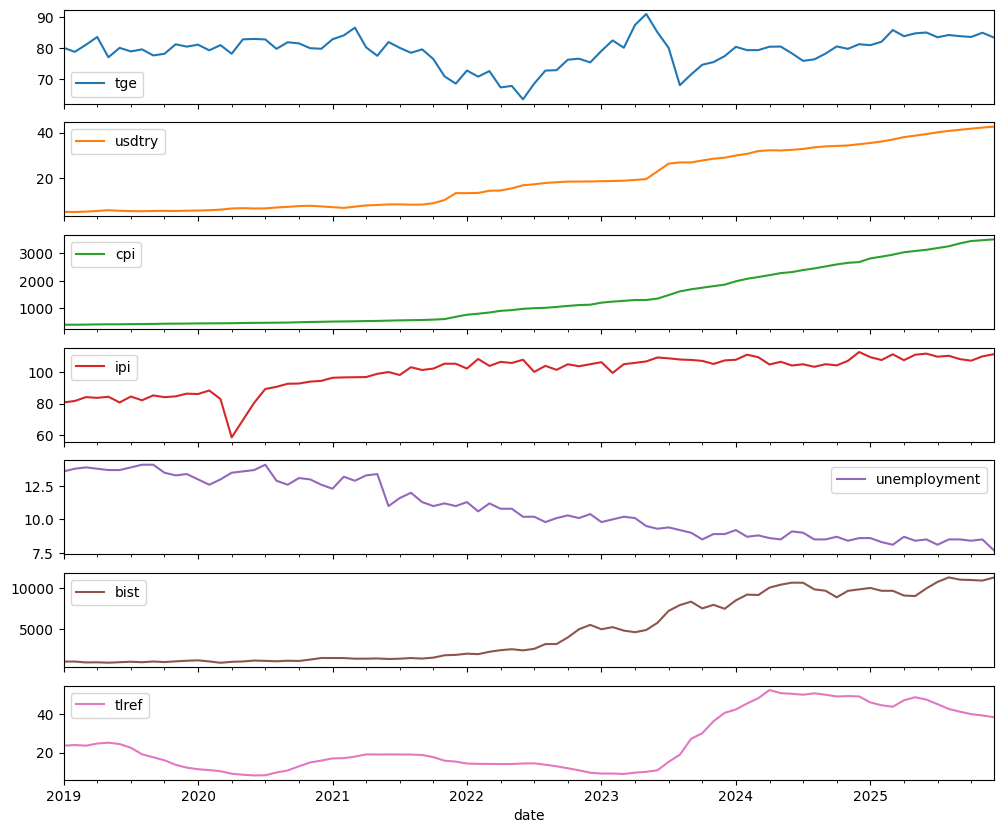

In [3]:
import matplotlib.pyplot as plt

macro.plot(subplots=True, figsize=(12,10))

plt.show()

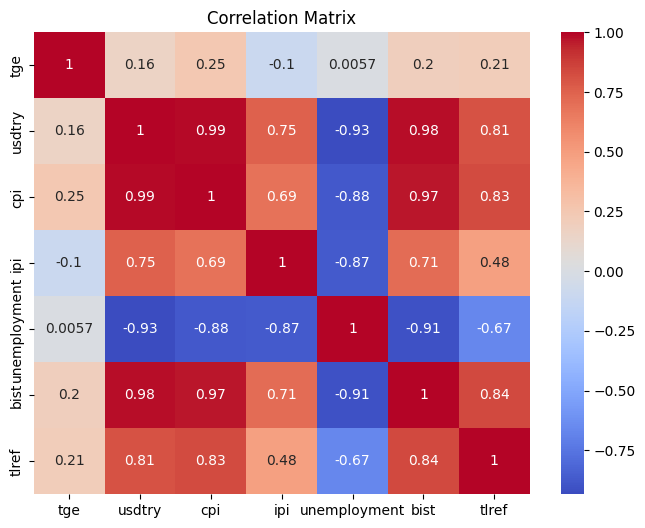

In [5]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(macro.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [6]:
macro.describe()

,tge,usdtry,cpi,ipi,unemployment,bist,tlref
count,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000
mean,79.066505,19.134674,1349.902857,99.326881,10.835714,4729.564048,24.862103
std,5.025656,12.561090,1004.684148,10.996316,2.070193,3853.170840,14.986199
min,63.410000,5.262055,398.070000,58.567604,7.700000,896.440000,8.097250
25%,76.929256,7.358529,484.837500,92.644174,8.775000,1184.862500,13.431774
50%,80.027056,17.176067,989.465000,103.980120,10.350000,2569.735000,18.811561
75%,82.178441,31.994388,2156.477500,107.343582,13.000000,9034.285000,40.813242
max,91.060000,42.586096,3513.870000,112.616751,14.100000,11288.050000,52.503088


| Variable     | Transformation |
| ------------ | -------------- |
| USDTRY       | log diff       |
| CPI          | log diff       |
| BIST         | log diff       |
| IPI          | log diff       |
| UNEMPLOYMENT | diff           |
| TLREF        | diff           |
| TGE          | şimdilik level |


İlk Öncelik: log serileri oluşturma

In [7]:
import numpy as np

macro_log = np.log(macro)

macro_log.head()

,tge,usdtry,cpi,ipi,unemployment,bist,tlref
date,,,,,,,
2019-01-01,4.383442,1.680714,5.986628,4.390794,2.610070,6.947687,3.160219
2019-02-01,4.366791,1.660522,5.988234,4.402235,2.624669,6.952059,3.174555
2019-03-01,4.395689,1.694135,5.998465,4.431775,2.631889,6.843579,3.160558
2019-04-01,4.426184,1.746722,6.015254,4.426179,2.624669,6.860831,3.206898
2019-05-01,4.344398,1.799967,6.024706,4.434475,2.617396,6.808929,3.224404


# log difference 
log(X_t) − log(X_{t-1})

In [8]:
macro_diff = macro_log.diff()

macro_diff.head()

,tge,usdtry,cpi,ipi,unemployment,bist,tlref
date,,,,,,,
2019-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-02-01,-0.016651,-0.020193,0.001606,0.011441,0.014599,0.004372,0.014336
2019-03-01,0.028898,0.033614,0.010231,0.029540,0.007220,-0.108480,-0.013997
2019-04-01,0.030494,0.052587,0.016789,-0.005597,-0.007220,0.017252,0.046339
2019-05-01,-0.081785,0.053244,0.009452,0.008297,-0.007273,-0.051902,0.017506


In [9]:
macro_diff = macro_diff.dropna()

macro_diff.head()

,tge,usdtry,cpi,ipi,unemployment,bist,tlref
date,,,,,,,
2019-02-01,-0.016651,-0.020193,0.001606,0.011441,0.014599,0.004372,0.014336
2019-03-01,0.028898,0.033614,0.010231,0.029540,0.007220,-0.108480,-0.013997
2019-04-01,0.030494,0.052587,0.016789,-0.005597,-0.007220,0.017252,0.046339
2019-05-01,-0.081785,0.053244,0.009452,0.008297,-0.007273,-0.051902,0.017506
2019-06-01,0.038803,-0.040053,0.000266,-0.043801,0.000000,0.063044,-0.027796


Stationarity Test (ADF)
# tüm seriler stationary olmalı

In [11]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    
    result = adfuller(series)
    
    print(f"ADF Test: {name}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("----------------------")

In [12]:
for column in macro_diff.columns:
    adf_test(macro_diff[column], column)

ADF Test: tge
ADF Statistic: -9.463070554750551
p-value: 4.3017323910252735e-16
----------------------
ADF Test: usdtry
ADF Statistic: -6.2621194447627415
p-value: 4.198559581109166e-08
----------------------
ADF Test: cpi
ADF Statistic: -4.502004918333366
p-value: 0.00019500610527381325
----------------------
ADF Test: ipi
ADF Statistic: -7.118369170530372
p-value: 3.778628743431757e-10
----------------------
ADF Test: unemployment
ADF Statistic: -9.392212876409573
p-value: 6.515153775043945e-16
----------------------
ADF Test: bist
ADF Statistic: -7.614444004504616
p-value: 2.2108745220551643e-11
----------------------
ADF Test: tlref
ADF Statistic: -3.1366481351228797
p-value: 0.02395728194901752
----------------------


log-difference transformation

| Variable           | Ekonomik yorum    |
| ------------------ | ----------------- |
| Δlog(usdtry)       | kur değişimi      |
| Δlog(cpi)          | enflasyon         |
| Δlog(bist)         | borsa getirisi    |
| Δlog(ipi)          | üretim büyümesi   |
| Δlog(unemployment) | işsizlik değişimi |
| Δlog(tlref)        | faiz değişimi     |
| Δlog(tge)          | güven değişimi    |
# Makro değişkenlerdeki değişimler
→ TGE değişimini açıklıyor mu?


# Model dataset ayrı kayıt
econometric model dataset

In [13]:
macro_diff.to_csv("../data/processed/macro_model_dataset_2019_2025.csv")